# DS 5001 Final Project

Erin Siedlecki

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
np.random.seed(42)

In [2]:
LIB = pd.read_csv('../data/LIB.csv', sep='|')
THETA = pd.read_csv('../data/LDA_THETA.csv', sep='|')
THETA = THETA.set_index(['artist', 'song'])
DOC_SENT = pd.read_csv('../data/DOC_SENT.csv', sep='|')

## Riff 1

In [3]:
SENT_RIFF = DOC_SENT.reset_index().groupby('artist')['sentiment'].mean().reset_index()
SENT_RIFF = SENT_RIFF.sort_values('sentiment', ascending=False)

fig = px.bar(SENT_RIFF, x='artist', y='sentiment', 
             title='Average Song Sentiment by Artist', 
             labels={'sentiment':'Average Sentiment', 'artist':'Artist'})

fig.write_image('../images/Riff_1.png')
fig.show()

This plot of average song sentiment by artist shows that the majority of artists have a positive sentiment, which is consistent with upbeat pop music. A few artists, such as Billie Eilish, Post Malone, and Maroon 5, have negative average sentiment, indicating that these artists have darker, more negative language in their music. Some of the artists that have more neutral average sentiment, such as Khalid and Coldplay, illustrate a mix of positive and negative content, which is consistent with their generally more emotional and serious pop songs.

## Riff 2

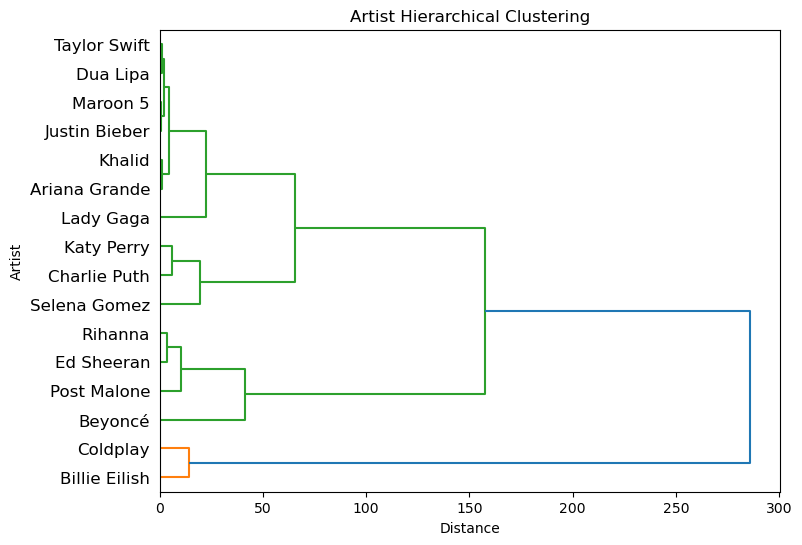

In [4]:
from scipy.cluster.hierarchy import linkage, dendrogram

cluster = LIB.merge(
    DOC_SENT[['artist','song','sentiment']],
    on = ['artist', 'song'], how = 'left')
feats = cluster.groupby('artist')[['doc_length_words', 'sentiment']].mean().dropna()
Z = linkage(feats, method='ward')
plt.figure(figsize=(8,6))
dendrogram(Z, labels=feats.index, orientation='right')
plt.title('Artist Hierarchical Clustering')
plt.xlabel('Distance')
plt.ylabel('Artist')
plt.savefig('../images/Riff_2.png', bbox_inches='tight')
plt.show()

This dendrogram shows a few clusters among artists that have similar average sentiment and song length. Coldplay and Billie Eilish are clustered together and merge at a farther distance from the remaining artists, suggesting that their music is less similar to the other artists. There is a large cluster among Taylor Swift, Dua Lipa, Maroon 5, and Justin Bieber, indicating that their songs have similar sentiment and length. The other artists have more sublte similarities as their clusters are smaller and more distant from the main pop group. Overall, this dendrogram highlights two distinct artists that share less similar sentiment and song length to the other pop artists.

## Riff 3

In [5]:
n_topics = 5
TNAMES = [f"T{str(x).zfill(2)}" for x in range(n_topics)]

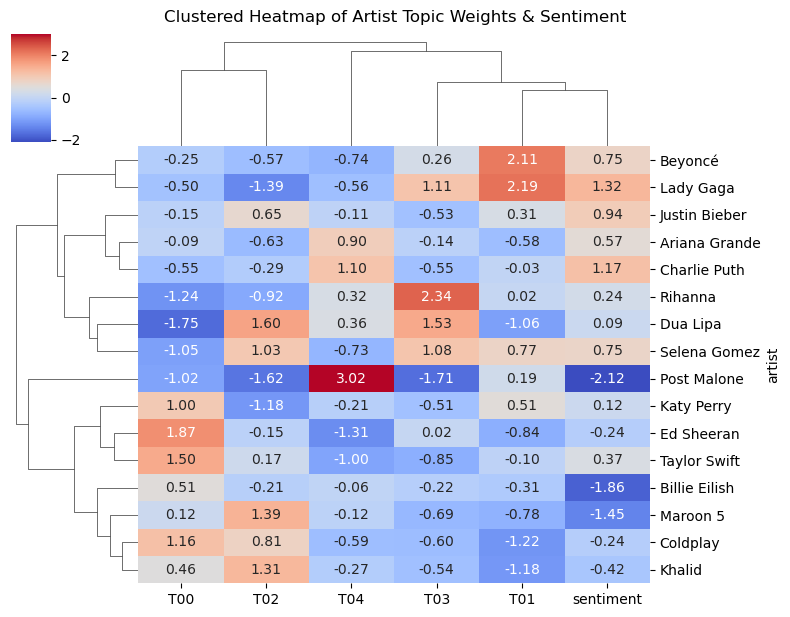

In [6]:
from sklearn.preprocessing import StandardScaler

cluster3 = THETA.reset_index().merge(
    LIB[['artist','song']], on=['artist', 'song'], how='left').merge(
    DOC_SENT[['artist','song','sentiment']],
    on = ['artist', 'song'], how = 'left')
feats3 = cluster3.groupby('artist')[TNAMES+['sentiment']].mean()
scaler = pd.DataFrame(
    StandardScaler().fit_transform(feats3),
    index=feats3.index,
    columns=feats3.columns
)

fig3 = sns.clustermap(scaler, cmap='coolwarm', 
               method='ward', figsize=(8,6),
              annot=True, fmt='.2f')
fig3.fig.suptitle('Clustered Heatmap of Artist Topic Weights & Sentiment', y=1.02)
fig3.savefig('../images/Riff_3.png')
plt.show()

Looking at the column dendrogram of topic weights and sentiment, T00 (topics related to reflection) and T02 (topics related to life) cluster closer together and merge at a farther distance to the other topics. This indicates that T00 and T02 have similar usage patterns among artists. Looking at the sentiment column, we can see that artists clustered together in the dendrogram have similar sentiments. Five pairs of artists are clustered together early on in the dendrogram. These pairs are Beyonce and Lady Gaga, Ariana Grande and Charlie Puth, Dua Lipa and Selena Gomez, Ed Sheeran and Taylor Swift, and Coldplay and Khalid. Among these pairs, except for Dua Lipa and Selena Gomez, the artists share similar sentiments. Additionally, the majority of these pairs have high values in the same topics. In particular, Beyonce and Lady Gaga have high values in T01, Ariana Grande and Charlie Puth have high values in T04, Dua Lipa and Selena Gomez have high values in T02 and T03, and Taylor Swift and Ed Sheeran have high values in T00.